##**Alumno: Carlos Alberto Vidrios Serrano**

# TAE-IA · Módulo 6 · L21 — Speech Synthesis: Three Ways to Make a Voice

| | |
|---|---|
| **Engines** | gTTS (cloud) · Piper `es_MX-claude-high` 63 MB (CPU) · XTTS-v2 1.9 GB (GPU) |
| **Also loads** | Whisper `small` 461 MB, for the round trip |
| **Runtime** | T4 GPU · ~2.5 GB on the runtime disk, re-downloaded each session |
| **Outputs** | `TAE_IA_M6/L21_output/` on Drive — a few MB of WAV files |

## Learning objectives

1. Synthesise the same Spanish text with three architecturally different engines and hear the difference
2. Move each engine's controls and connect every knob to the model part it scales
3. Measure intelligibility (round-trip WER through Whisper) and speed (real-time factor) honestly
4. Run a blind listening test and compare what the room hears with what the metrics say

## 1 — Setup

Colab does not ship `coqui-tts`, `piper-tts` or `gtts`. The `[codec]` extra pulls in `torchcodec`,
which `torchaudio` needs for audio I/O from torch 2.9 on. About two minutes.

In [1]:
!pip install -q "coqui-tts[codec]" gtts piper-tts jiwer openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 28.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.3/997.3 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 639.3/639.3 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

**Two warnings you can ignore today:**
- pip's red *"dependency resolver … diffusers requires huggingface-hub>=1.23"* (and `click` for
  wandb/spacy). `coqui-tts` pins an older `huggingface_hub`; nothing in this lab uses diffusers, wandb
  or spacy. It *would* matter in a notebook that also loads a diffusers pipeline.
- `[transformers] Model config: bos_token_id must be None or an integer within the vocabulary…` when
  XTTS loads. XTTS's GPT uses its own audio-code vocabulary; the check is written for text models.

In [2]:
import os, re, time, random, wave
import numpy as np
import torch

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/TAE_IA_M6'
OUTPUT_DIR = f'{DRIVE_ROOT}/L21_output'
INPUT_DIR  = f'{DRIVE_ROOT}/inputs'
CLIPS      = f'{OUTPUT_DIR}/clips'
for d in (OUTPUT_DIR, INPUT_DIR, CLIPS):
    os.makedirs(d, exist_ok=True)

# Weights on the runtime disk: fast, no Drive symlink bug, wiped between sessions.
MODEL_CACHE = '/content/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
os.environ['HF_HOME']  = MODEL_CACHE
os.environ['TTS_HOME'] = f'{MODEL_CACHE}/tts'
os.environ['COQUI_TOS_AGREED'] = '1'   # XTTS-v2: Coqui Public Model License, non-commercial use only

if not torch.cuda.is_available():
    raise SystemExit('No GPU. Runtime > Change runtime type > T4 GPU')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def vram(tag=''):
    used  = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  VRAM {used:5.2f} / {total:.1f} GB   {tag}')

print(torch.cuda.get_device_name(0)); vram('empty')

Mounted at /content/drive
Tesla T4
  VRAM  0.00 / 15.6 GB   empty


In [3]:
# coqui-tts 0.27 still imports a helper that transformers 5.1 removed
# (idiap/coqui-ai-TTS issue #558). Put it back BEFORE importing TTS.
import transformers, transformers.pytorch_utils as pu
if not hasattr(pu, 'isin_mps_friendly'):
    pu.isin_mps_friendly = torch.isin
    print(f'transformers {transformers.__version__}: compatibility alias added')

import soundfile as sf, librosa, librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
from gtts import gTTS
from piper import PiperVoice, SynthesisConfig
from huggingface_hub import hf_hub_download
from TTS.api import TTS
%matplotlib inline
# ^ Importing TTS switches matplotlib to the non-interactive 'Agg' backend
#   (TTS/tts/utils/visual.py calls matplotlib.use("Agg")), which silently hides every plot.
#   This line switches it back. Without it, Parts 2 and 3 show no figures.

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

def seconds(path):
    info = sf.info(path)
    return info.frames / info.samplerate

def play(path, label=''):
    print(f'{label:28s} {seconds(path):5.2f} s   {os.path.basename(path)}')
    ipd.display(ipd.Audio(path))

transformers 5.16.1: compatibility alias added


## 2 — Three engines behind one interface

Each `synth_*` function takes text and a clip name, writes a WAV to `CLIPS`, and returns
`(path, synthesis_seconds)`. Same signature for all three, so everything after this cell treats
them identically.

- **gTTS** sends the text to Google Translate's TTS service. `tld` picks the accent.
- **Piper** runs a VITS voice on the CPU through ONNX Runtime.
- **XTTS-v2** runs a 443M-parameter GPT-2 plus a HiFi-GAN decoder on the GPU.

In [4]:
def synth_gtts(text, name, tld='com.mx'):
    mp3, wav = f'{CLIPS}/{name}.mp3', f'{CLIPS}/{name}.wav'
    t0 = time.time()
    gTTS(text=text, lang='es', tld=tld).save(mp3)
    dt = time.time() - t0                          # network + synthesis, the user's view
    y, sr = librosa.load(mp3, sr=None)             # MP3 -> WAV so every engine is measured the same way
    sf.write(wav, y, sr)
    return wav, dt

PIPER_STEM = 'es/es_MX/claude/high/es_MX-claude-high'
piper_onnx = hf_hub_download('rhasspy/piper-voices', PIPER_STEM + '.onnx', local_dir=f'{MODEL_CACHE}/piper')
hf_hub_download('rhasspy/piper-voices', PIPER_STEM + '.onnx.json', local_dir=f'{MODEL_CACHE}/piper')
piper_voice = PiperVoice.load(piper_onnx)
print('Piper sample rate:', piper_voice.config.sample_rate)

def synth_piper(text, name, **knobs):              # knobs: length_scale, noise_scale, noise_w_scale
    wav = f'{CLIPS}/{name}.wav'
    t0 = time.time()
    with wave.open(wav, 'wb') as wf:
        piper_voice.synthesize_wav(text, wf, syn_config=SynthesisConfig(**knobs))
    return wav, time.time() - t0

t0 = time.time()
xtts = TTS('tts_models/multilingual/multi-dataset/xtts_v2').to('cuda')
print(f'XTTS-v2 loaded in {time.time()-t0:.0f} s'); vram('XTTS-v2 resident')
print(f'{len(xtts.speakers)} built-in speakers, e.g. {xtts.speakers[:6]}')
XTTS_SPEAKER = xtts.speakers[0]

def synth_xtts(text, name, speaker=None, speaker_wav=None, **gen):   # gen: temperature, top_p, speed, ...
    wav = f'{CLIPS}/{name}.wav'
    if speaker_wav is None and speaker is None:
        speaker = XTTS_SPEAKER
    torch.cuda.synchronize(); t0 = time.time()
    xtts.tts_to_file(text=text, language='es', file_path=wav,
                     speaker=speaker, speaker_wav=speaker_wav, **gen)
    torch.cuda.synchronize()
    return wav, time.time() - t0

ENGINES = {'gtts': synth_gtts, 'piper': synth_piper, 'xtts': synth_xtts}

es/es_MX/claude/high/es_MX-claude-high.o(…):   0%|          | 0.00/63.1M [00:00<?, ?B/s]

es_MX-claude-high.onnx.json:   0%|          | 0.00/4.96k [00:00<?, ?B/s]

Piper sample rate: 22050


100%|██████████| 1.87G/1.87G [00:28<00:00, 66.0MiB/s]
4.37kiB [00:00, 6.08MiB/s]
361kiB [00:00, 80.2MiB/s]
100%|██████████| 32.0/32.0 [00:00<00:00, 56.8kiB/s]
100%|██████████| 7.75M/7.75M [00:00<00:00, 17.7MiB/s]
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 255), got 50256. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 255), got 50256. This may result in unexpected behavior.
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 607), got 50256. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 607), got 50256. This may result in unexpected behavior.


XTTS-v2 loaded in 51 s
  VRAM  1.87 / 15.6 GB   XTTS-v2 resident
58 built-in speakers, e.g. ['Claribel Dervla', 'Daisy Studious', 'Gracie Wise', 'Tammie Ema', 'Alison Dietlinde', 'Ana Florence']


## 3 — Part 1: the same sentences, three voices

Four sentences, each chosen to stress one stage of the pipeline:

| Key | Stresses |
|---|---|
| `probe` | the front-end: an abbreviation, a number and a date in one line |
| `fourier` | grapheme-to-phoneme on a French loanword |
| `question` | prosody: the rising pitch of a question |
| `long` | the stop decision and long-range rhythm |

In [5]:
SENTENCES = {
    'probe':    'El Dr. Pérez midió 128 bandas el 15/09/2026.',
    'fourier':  'La transformada de Fourier revela las componentes de frecuencia de una señal.',
    'question': '¿Ya terminaste de entrenar el modelo, o todavía te falta la última época?',
    'long':     ('Los sistemas de síntesis de voz trabajan en tres etapas: normalizan el texto, '
                 'deciden la prosodia y reconstruyen la forma de onda con un vocoder.'),
}

clips = {}                                  # (engine, sentence) -> (path, synthesis seconds)
for key, text in SENTENCES.items():
    print(f'\n=== {key}: {text}')
    for eng, fn in ENGINES.items():
        clips[(eng, key)] = fn(text, f'p1_{eng}_{key}')
        play(clips[(eng, key)][0], eng)


=== probe: El Dr. Pérez midió 128 bandas el 15/09/2026.
gtts                          7.34 s   p1_gtts_probe.wav


piper                         6.16 s   p1_piper_probe.wav


xtts                          6.17 s   p1_xtts_probe.wav



=== fourier: La transformada de Fourier revela las componentes de frecuencia de una señal.
gtts                          6.17 s   p1_gtts_fourier.wav


piper                         4.42 s   p1_piper_fourier.wav


...

piper                         4.78 s   p1_piper_question.wav


xtts                          5.47 s   p1_xtts_question.wav



=== long: Los sistemas de síntesis de voz trabajan en tres etapas: normalizan el texto, deciden la prosodia y reconstruyen la forma de onda con un vocoder.
gtts                         11.64 s   p1_gtts_long.wav


piper                         9.38 s   p1_piper_long.wav


xtts                          9.14 s   p1_xtts_long.wav


**Listen before you measure.** For each sentence, write one line per engine: did it read *Dr.*,
*128* and the date correctly? Did *Fourier* come out French, Spanish-spelled, or broken? Did the
question actually rise at the end?

*Your notes:*

### XTTS clones — one sentence, two voices

XTTS takes a **reference clip** instead of a built-in speaker. Here the reference is gTTS's own
Mexican voice: XTTS imitates a voice that is itself synthetic. Cloning real people — and whether
you should — is L22.

In [6]:
ref_wav, _ = synth_gtts('Hola. Ésta es la voz de referencia que XTTS va a imitar en los siguientes segundos.',
                        'ref_gtts_mx')
clone_wav, _ = synth_xtts(SENTENCES['question'], 'p1_xtts_clone_gtts', speaker_wav=ref_wav)
play(ref_wav, 'reference (gTTS com.mx)')
play(clips[('xtts', 'question')][0], f'XTTS built-in: {XTTS_SPEAKER}')
play(clone_wav, 'XTTS cloning the reference')

reference (gTTS com.mx)       7.32 s   ref_gtts_mx.wav


XTTS built-in: Claribel Dervla  5.47 s   p1_xtts_question.wav


XTTS cloning the reference    5.29 s   p1_xtts_clone_gtts.wav


## 4 — Part 2: every knob maps to a part of the model

**Piper** exposes VITS's three noise knobs. **XTTS** exposes the GPT's sampling parameters.
Predict before you run: which Piper knob changes the *length* of the clip, and which only changes
how it *sounds*?

In [7]:
TEXT = SENTENCES['question']
variants = {}
for ls in (0.8, 1.0, 1.4):
    variants[f'piper length_scale={ls}'] = synth_piper(TEXT, f'p2_piper_ls{ls}', length_scale=ls)[0]
for ns in (0.0, 0.667, 1.2):
    variants[f'piper noise_scale={ns}'] = synth_piper(TEXT, f'p2_piper_ns{ns}', noise_scale=ns)[0]
for temp in (0.3, 0.75, 1.1):
    torch.manual_seed(SEED)                      # same seed: only the temperature differs
    variants[f'xtts temperature={temp}'] = synth_xtts(TEXT, f'p2_xtts_t{temp}', temperature=temp)[0]
for sp in (0.8, 1.25):
    torch.manual_seed(SEED)
    variants[f'xtts speed={sp}'] = synth_xtts(TEXT, f'p2_xtts_sp{sp}', speed=sp)[0]

for label, path in variants.items():
    play(path, label)

piper length_scale=0.8        4.17 s   p2_piper_ls0.8.wav


piper length_scale=1.0        4.83 s   p2_piper_ls1.0.wav


piper length_scale=1.4        6.07 s   p2_piper_ls1.4.wav


piper noise_scale=0.0         4.75 s   p2_piper_ns0.0.wav


piper noise_scale=0.667       4.74 s   p2_piper_ns0.667.wav


...

xtts temperature=0.3          4.92 s   p2_xtts_t0.3.wav


xtts temperature=0.75         4.68 s   p2_xtts_t0.75.wav


xtts temperature=1.1          5.01 s   p2_xtts_t1.1.wav


xtts speed=0.8                5.75 s   p2_xtts_sp0.8.wav


xtts speed=1.25               3.80 s   p2_xtts_sp1.25.wav


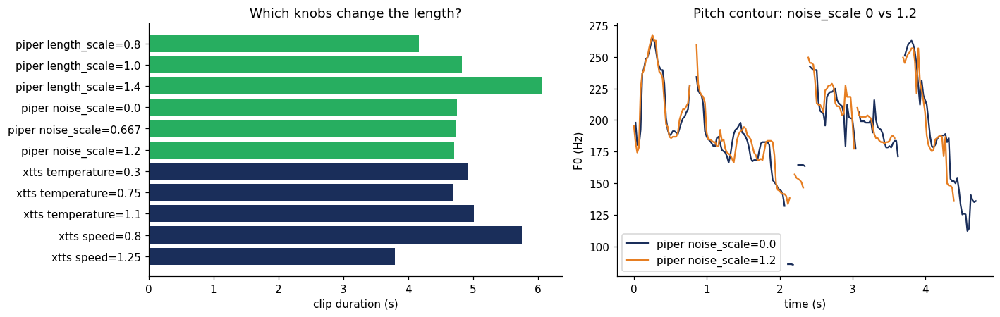

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={'width_ratios': [1.1, 1]})
labels = list(variants)
ax1.barh(labels, [seconds(variants[k]) for k in labels], color=['#27ae60'] * 6 + ['#1a2e5a'] * 5)
ax1.invert_yaxis(); ax1.set_xlabel('clip duration (s)'); ax1.set_title('Which knobs change the length?')

for k, c in zip(['piper noise_scale=0.0', 'piper noise_scale=1.2'], ['#1a2e5a', '#e67e22']):
    y, sr = librosa.load(variants[k], sr=None)
    f0, voiced, _ = librosa.pyin(y, fmin=70, fmax=400, sr=sr)
    t = librosa.times_like(f0, sr=sr)
    ax2.plot(t, f0, color=c, label=k)
ax2.set_xlabel('time (s)'); ax2.set_ylabel('F0 (Hz)'); ax2.legend(); ax2.set_title('Pitch contour: noise_scale 0 vs 1.2')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/p2_knobs.png'); plt.show()

**Observation.** Which knobs changed the duration, and by exactly the factor you set — or less? Did
`noise_scale` change the pitch contour at all? If not, where in VITS is the melody decided, and what
*does* the noise change when you listen? At what XTTS temperature did the first real mistake appear?

*Your answer:*

## 5 — Part 3: the round trip — WER and real-time factor

Whisper transcribes every clip from Part 1 and we score it against the text we wrote.

**Two measurement rules from the slides:**
1. **Normalise both sides the same way** — Whisper writes `128`, the reference may say *ciento
   veintiocho*. `normalise_es` expands numbers, the date and `Dr.` on *both* strings.
2. **Warm up before timing** (L06). The first call to each engine pays one-off costs.

In [9]:
import whisper
from jiwer import wer
from num2words import num2words

asr = whisper.load_model('small', download_root=f'{MODEL_CACHE}/whisper')
vram('XTTS + Whisper small')

MESES = ['', 'enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 'julio', 'agosto',
         'septiembre', 'octubre', 'noviembre', 'diciembre']

def normalise_es(text):
    t = text.lower()
    t = re.sub(r'(\d{1,2})/(\d{1,2})/(\d{4})',
               lambda m: f"{num2words(int(m[1]), lang='es')} de {MESES[int(m[2])]} de {num2words(int(m[3]), lang='es')}", t)
    t = re.sub(r'\bdr\.?\s', 'doctor ', t)
    t = re.sub(r'\d+', lambda m: num2words(int(m[0]), lang='es'), t)
    t = re.sub(r'[^a-záéíóúüñ\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

print(normalise_es(SENTENCES['probe']))
print(normalise_es('El doctor Pérez midió 128 bandas el 15 de septiembre de 2026.'))

100%|████████████████████████████████████████| 461M/461M [00:01<00:00, 295MiB/s]


  VRAM  2.85 / 15.6 GB   XTTS + Whisper small
el doctor pérez midió ciento veintiocho bandas el quince de septiembre de dos mil veintiséis
el doctor pérez midió ciento veintiocho bandas el quince de septiembre de dos mil veintiséis


In [10]:
import pandas as pd

for eng, fn in ENGINES.items():                     # warm-up: one short call each, not timed
    fn('Prueba.', f'warmup_{eng}')

rows = []
for key, text in SENTENCES.items():
    for eng, fn in ENGINES.items():
        path, dt = fn(text, f'p3_{eng}_{key}')
        hyp = asr.transcribe(path, language='es', fp16=True)['text'].strip()
        rows.append({'engine': eng, 'sentence': key, 'synth_s': dt, 'audio_s': seconds(path),
                     'RTF': dt / seconds(path), 'WER': wer(normalise_es(text), normalise_es(hyp)),
                     'heard': hyp})

df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 90)
display(df.round(3))
summary = df.groupby('engine')[['RTF', 'WER']].mean().round(3)
display(summary)
df.to_csv(f'{OUTPUT_DIR}/p3_roundtrip.csv', index=False)

,engine,sentence,synth_s,audio_s,RTF,WER,heard
0,gtts,probe,1.157,7.344,0.158,0.000,El doctor Pérez midió 128 bandas el 15 de septiembre de 2026.
1,piper,probe,2.293,6.269,0.366,0.267,El doctor Perez midió 128 bandas el 15 vara 09 vara 2026.
2,xtts,probe,3.066,4.918,0.623,0.267,el doctor Pérez Millo 128 bandas el 15-9-2026.
3,gtts,fourier,1.139,6.168,0.185,0.000,La transformada de Fourier revela las componentes de frecuencia de una señal.
4,piper,fourier,1.433,4.319,0.332,0.000,La transformada de Fourier revela las componentes de frecuencia de una señal.
5,xtts,fourier,3.632,5.611,0.647,0.083,La transformada de Fourier revela las componentes de frecuencia de una señal.qn.
6,gtts,question,1.164,5.904,0.197,0.000,"¿Ya terminaste de entrenar el modelo, o todavía te falta la última época?"
7,piper,question,1.788,4.690,0.381,0.000,"Ya terminaste de entrenar el modelo, o todavía te falta la última época."
8,xtts,question,3.221,4.587,0.702,0.000,¿Ya terminaste de entrenar el modelo? ¿O todavía te falta la última época?
9,gtts,long,1.501,11.664,0.129,0.040,Los sistemas de síntesis de voz trabajan en tres etapas. Normalizan el texto. Deciden ...


,RTF,WER
engine,,
gtts,0.167,0.010
piper,0.328,0.077
xtts,0.661,0.098


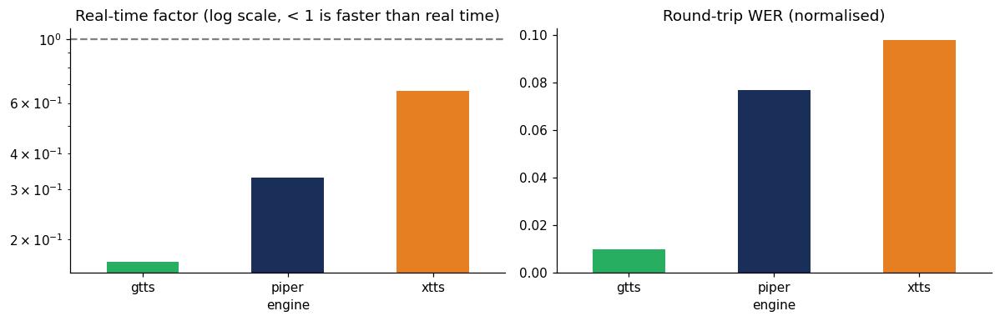

XTTS, unseeded                9.61 s   p3_xtts_twice_1.wav


   heard: Los sistemas de síntesis de voz trabajan en tres etapas. Normalizan el texto. Deciden la prosodia y reconstruyen la forma de onda con un bocodeo.
XTTS, unseeded               10.11 s   p3_xtts_twice_2.wav


   heard: Los sistemas de síntesis de voz trabajan en tres etapas. Normalizan el texto, deciden la prosodia, y reconstruyen la forma de onda con un bocode.


In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
summary['RTF'].plot.bar(ax=a1, color=['#27ae60', '#1a2e5a', '#e67e22'], logy=True)
a1.axhline(1, ls='--', c='grey'); a1.set_title('Real-time factor (log scale, < 1 is faster than real time)')
summary['WER'].plot.bar(ax=a2, color=['#27ae60', '#1a2e5a', '#e67e22'])
a2.set_title('Round-trip WER (normalised)')
for a in (a1, a2): a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/p3_rtf_wer.png'); plt.show()

# The same XTTS call twice, no fixed seed: does the transcript change, or only the sound?
torch.manual_seed(int(time.time()))
twice = [synth_xtts(SENTENCES['long'], f'p3_xtts_twice_{i}')[0] for i in (1, 2)]
for p in twice:
    play(p, 'XTTS, unseeded')
    print('   heard:', asr.transcribe(p, language='es', fp16=True)['text'].strip())

**Observation.** Fill in the RTF cell for XTTS in your copy of the *Three Engines, One Table*
slide. Which engine had the highest WER, and on which sentence? **Listen to every clip whose WER is
not 0** and decide: engine error, normalisation mismatch, or Whisper's mistake? Did the two unseeded
XTTS runs transcribe identically?

*Your answer:*

## 6 — Part 4: a blind listening test

Six clips, shuffled, labels hidden. Rate each one **1 (bad) to 5 (excellent)** for naturalness
*before* revealing which engine made it. Better still: swap laptops with your neighbour and rate
theirs.

In [12]:
rng = random.Random()                               # deliberately unseeded: a different order per student
pool = [(eng, key) for key in ('question', 'long') for eng in ENGINES]
rng.shuffle(pool)
LETTERS = 'ABCDEF'
blind = dict(zip(LETTERS, pool))
for letter, (eng, key) in blind.items():
    print(f'Clip {letter}')
    ipd.display(ipd.Audio(clips[(eng, key)][0]))

Clip A


Clip B


Clip C


Clip D


Clip E


Clip F


In [13]:
# Rate every clip 1-5 BEFORE running the reveal cell.
RATINGS = {'A': None, 'B': None, 'C': None, 'D': None, 'E': None, 'F': None}

In [14]:
missing = [k for k, v in RATINGS.items() if v is None]
if missing:
    print(f'Rate clips {missing} first.')
else:
    reveal = pd.DataFrame([{'clip': k, 'engine': blind[k][0], 'sentence': blind[k][1], 'rating': v}
                           for k, v in RATINGS.items()])
    display(reveal)
    mos = reveal.groupby('engine')['rating'].agg(['mean', 'count']).round(2)
    display(mos.join(summary))
    reveal.to_csv(f'{OUTPUT_DIR}/p4_blind_ratings.csv', index=False)

Rate clips ['A', 'B', 'C', 'D', 'E', 'F'] first.


**Observation.** Did your naturalness ranking match the WER ranking from Part 3? With two ratings
per engine from one listener, what can this "MOS" honestly claim — and what would it take to make it
a real one? When the instructor collects the room's scores, does your ranking agree with the room's?

*Your answer:*

## Exercise 1 — Break the front-end

Write **five Spanish sentences** that each attack the text front-end in a different way — pick from:
an ordinal (*3er*), money (*$1,250.50*), a time (*14:30 h*), an acronym (*UNAM*, *CFE*), an English
brand (*YouTube*, *Wi-Fi*), a unit (*5 km/h*), a phone number, Roman numerals (*siglo XXI*).

For every sentence × engine: synthesise, run the round trip, **listen**, and label each error as
**front-end** (read wrong), **engine** (pronounced badly or skipped) or **ASR** (Whisper's mistake).

In [15]:
# Exercise 1 -- Break the front-end
# Given: ENGINES, asr, normalise_es, wer, play, pd are all defined above.

#MY_SENTENCES = [
    # TODO 1: five sentences, each attacking the front-end differently
#]

# TODO 2: for each sentence and each engine, synthesise with a unique clip name ('ex1_...'),
#         transcribe with asr (language='es', fp16=True), and compute WER on normalised text.
# TODO 3: collect the results in a DataFrame and display it.
# TODO 4: listen to every clip with WER > 0 and write your error labels in the cell below.


import pandas as pd
import matplotlib.pyplot as plt

# TODO 1: Five sentences, each attacking the front-end differently
MY_SENTENCES = [
    "El 3er lugar ganó $1,250.50 en el sorteo.",           # Ordinal + Money
    "La conferencia comienza a las 14:30 h.",              # Time (24h)
    "La UNAM y la CFE firmaron un acuerdo importante.",    # Acronyms
    "Descargué videos de YouTube y pasé el Wi-Fi.",        # English brands
    "Corrimos 5 km/h en la competencia del siglo XXI.",    # Units + Roman
]

print(f"Testing {len(MY_SENTENCES)} sentences:")
for i, s in enumerate(MY_SENTENCES, 1):
    print(f"{i}. {s}")

# TODO 2 & 3: Synthesize, transcribe, compute WER
rows_ex1 = []
for idx, sentence in enumerate(MY_SENTENCES, 1):
    for eng, fn in ENGINES.items():
        # Synthesize
        path, dt = fn(sentence, f'ex1_sentence_{idx}_{eng}')

        # Transcribe
        hyp = asr.transcribe(path, language='es', fp16=True)['text'].strip()

        # Compute WER
        ref_norm = normalise_es(sentence)
        hyp_norm = normalise_es(hyp)
        error_rate = wer(ref_norm, hyp_norm)

        rows_ex1.append({
            'sentence_id': idx,
            'sentence': sentence,
            'engine': eng,
            'transcribed': hyp,
            'WER': round(error_rate, 3),
            'RTF': round(dt / seconds(path), 3)
        })

df_ex1 = pd.DataFrame(rows_ex1)
display(df_ex1)

# Export to CSV for reference
df_ex1.to_csv(f'{OUTPUT_DIR}/ex1_results.csv', index=False)
print("\n✓ Results saved to ex1_results.csv\n")

# TODO 4: Listen to every clip with WER > 0
print("="*70)
print("LISTENING: Clips with WER > 0 (errors detected)")
print("="*70)

error_clips = df_ex1[df_ex1['WER'] > 0].sort_values('WER', ascending=False)
if len(error_clips) == 0:
    print("No errors found! All clips are perfect.")
else:
    for idx, row in error_clips.iterrows():
        print(f"\n▶ Sentence {row['sentence_id']} | {row['engine']} | WER={row['WER']}")
        print(f"  Expected: {row['sentence']}")
        print(f"  Got:      {row['transcribed']}")
        play(f"{CLIPS}/ex1_sentence_{row['sentence_id']}_{row['engine']}.wav",
             f"{row['engine']}")




Testing 5 sentences:
1. El 3er lugar ganó $1,250.50 en el sorteo.
2. La conferencia comienza a las 14:30 h.
3. La UNAM y la CFE firmaron un acuerdo importante.
4. Descargué videos de YouTube y pasé el Wi-Fi.
5. Corrimos 5 km/h en la competencia del siglo XXI.


,sentence_id,sentence,engine,transcribed,WER,RTF
0,1,"El 3er lugar ganó $1,250.50 en el sorteo.",gtts,El tercer lugar ganó 1.250 dólares y 50 centavos en el sorteo.,0.364,0.174
1,1,"El 3er lugar ganó $1,250.50 en el sorteo.",piper,"El tercer lugar ganó dólar 1,250 en el sorteo.",0.273,0.387
2,1,"El 3er lugar ganó $1,250.50 en el sorteo.",xtts,El tercero lugar ganó dólar 1.25. 50. En el sorteo.num.,0.455,0.658
3,2,La conferencia comienza a las 14:30 h.,gtts,La conferencia comienza a las 2.30 de la tarde.,0.500,0.278
4,2,La conferencia comienza a las 14:30 h.,piper,La conferencia comienza a las 14.30.,0.125,0.411
5,2,La conferencia comienza a las 14:30 h.,xtts,La conferencia comienza a las 14.30.,0.125,0.882
6,3,La UNAM y la CFE firmaron un acuerdo importante.,gtts,La UNAM y la CFE firmaron un acuerdo importante.,0.000,0.244
7,3,La UNAM y la CFE firmaron un acuerdo importante.,piper,La UNAM y la CF firmaron un acuerdo importante.,0.111,0.317
8,3,La UNAM y la CFE firmaron un acuerdo importante.,xtts,la UNAM y la CF firmaron un acuerdo importante.,0.111,0.703
9,4,Descargué videos de YouTube y pasé el Wi-Fi.,gtts,Descargué vídeos de YouTube y pasé el wifi.,0.333,0.291



✓ Results saved to ex1_results.csv

LISTENING: Clips with WER > 0 (errors detected)

▶ Sentence 2 | gtts | WER=0.5
  Expected: La conferencia comienza a las 14:30 h.
  Got:      La conferencia comienza a las 2.30 de la tarde.
gtts                          3.89 s   ex1_sentence_2_gtts.wav



▶ Sentence 1 | xtts | WER=0.455
  Expected: El 3er lugar ganó $1,250.50 en el sorteo.
  Got:      El tercero lugar ganó dólar 1.25. 50. En el sorteo.num.
xtts                          8.73 s   ex1_sentence_1_xtts.wav



▶ Sentence 4 | piper | WER=0.444
  Expected: Descargué videos de YouTube y pasé el Wi-Fi.
  Got:      Descargé vídeos de YouTube y pasé el wifi.
piper                         3.45 s   ex1_sentence_4_piper.wav


...


▶ Sentence 2 | piper | WER=0.125
  Expected: La conferencia comienza a las 14:30 h.
  Got:      La conferencia comienza a las 14.30.
piper                         3.10 s   ex1_sentence_2_piper.wav



▶ Sentence 2 | xtts | WER=0.125
  Expected: La conferencia comienza a las 14:30 h.
  Got:      La conferencia comienza a las 14.30.
xtts                          3.24 s   ex1_sentence_2_xtts.wav



▶ Sentence 3 | xtts | WER=0.111
  Expected: La UNAM y la CFE firmaron un acuerdo importante.
  Got:      la UNAM y la CF firmaron un acuerdo importante.
xtts                          4.36 s   ex1_sentence_3_xtts.wav



▶ Sentence 3 | piper | WER=0.111
  Expected: La UNAM y la CFE firmaron un acuerdo importante.
  Got:      La UNAM y la CF firmaron un acuerdo importante.
piper                         4.13 s   ex1_sentence_3_piper.wav



▶ Sentence 5 | piper | WER=0.1
  Expected: Corrimos 5 km/h en la competencia del siglo XXI.
  Got:      Corrimos 5 km vara H en la competencia del siglo XXI.
piper                         4.69 s   ex1_sentence_5_piper.wav


**Exercise 1 — Answer:** a table of your error labels, then: which engine's front-end was the most
robust, and which error type dominated overall? Name one error that `normalise_es` itself
introduced or hid.

*Your answer:*

## Exercise 2 — Does the real-time factor stay constant?

Measure RTF for **Piper and XTTS** on texts of roughly **5, 20, 60 and 150 words**, built from
whole sentences so they keep their full stops. Plot RTF against word count for both engines.

Is RTF constant as the text grows? Then the XTTS experiment: `tts_to_file` **splits text into
sentences by default** and synthesises them one at a time. Run the 150-word text again with
`split_sentences=False` — one pass, far past XTTS's 239-character limit for Spanish — and compare
time and sound. Read the warning coqui-tts prints.

TEXTOS GENERADOS

Objetivo: 5 palabras
Palabras reales: 25
Los sistemas de síntesis de voz trabajan en tres etapas: normalizan el texto, deciden la prosodia y reconstruyen la forma de onda con un vocoder.

Objetivo: 20 palabras
Palabras reales: 25
Los sistemas de síntesis de voz trabajan en tres etapas: normalizan el texto, deciden la prosodia y reconstruyen la forma de onda con un vocoder.

Objetivo: 60 palabras
Palabras reales: 75
Los sistemas de síntesis de voz trabajan en tres etapas: normalizan el texto, deciden la prosodia y reconstruyen la forma de onda con un vocoder. Los sistemas de síntesis de voz trabajan en tres etapas: normalizan el texto, deciden la prosodia y reconstruyen la forma de onda con un vocoder. Los sistemas de síntesis de voz trabajan en tres etapas: normalizan el texto, deciden la prosodia y reconstruyen la forma de onda con un vocoder.

Objetivo: 150 palabras
Palabras reales: 150
Los sistemas de síntesis de voz trabajan en tres etapas: normalizan el texto, de

,target_words,words,engine,synth_s,audio_s,RTF,mode
0,5,25,piper,2.714,9.323,0.291,default
1,5,25,xtts,6.131,9.889,0.620,split_sentences=True
2,20,25,piper,2.080,9.207,0.226,default
3,20,25,xtts,6.571,10.305,0.638,split_sentences=True
4,60,75,piper,4.601,27.829,0.165,default
5,60,75,xtts,16.320,29.986,0.544,split_sentences=True
6,150,150,piper,10.292,55.937,0.184,default
7,150,150,xtts,31.170,60.089,0.519,split_sentences=True


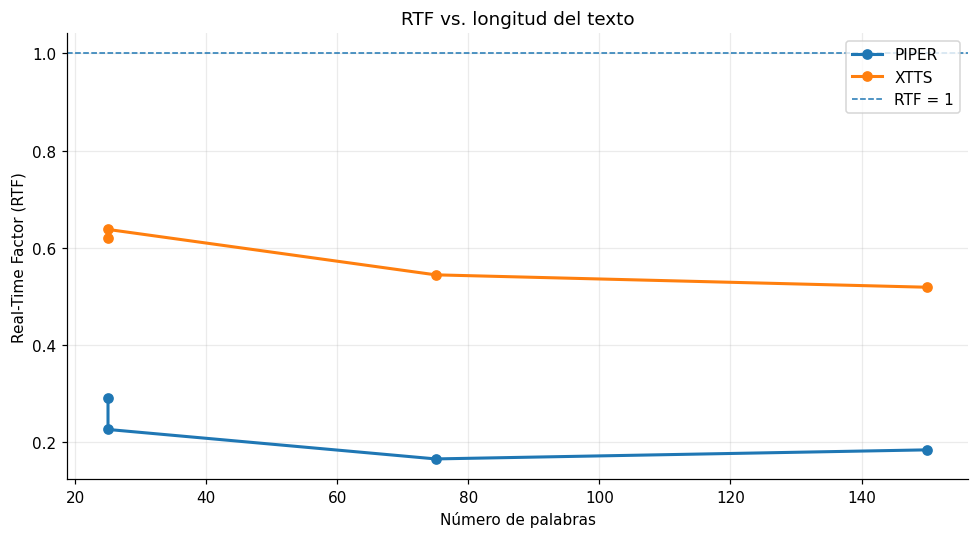


XTTS — 150 WORDS — split_sentences=False


AssertionError:  ❗ XTTS can only generate text with a maximum of 400 tokens.

In [16]:
# ============================================================
# Exercise 2 -- RTF vs. text length
# ============================================================
# Given:
# synth_piper, synth_xtts, seconds, plt

SHORT = '¿Ya terminaste?'

LONG = SENTENCES['long']

# ------------------------------------------------------------
# Construcción de textos de diferentes longitudes
# ------------------------------------------------------------

def make_text(target_words):
    """
    Construye un texto aproximado al número de palabras solicitado
    utilizando únicamente frases completas.
    """

    sentences = []

    # Primero agregamos frases completas LONG
    while len(" ".join(sentences).split()) < target_words:
        sentences.append(LONG)

    # Si el texto queda ligeramente por encima del objetivo,
    # seguimos manteniendo la última frase completa.
    return " ".join(sentences)


TARGET_WORDS = [5, 20, 60, 150]

texts = {}

for target in TARGET_WORDS:
    texts[target] = make_text(target)

print("TEXTOS GENERADOS")
print("=" * 70)

for target, text in texts.items():
    print(f"\nObjetivo: {target} palabras")
    print(f"Palabras reales: {len(text.split())}")
    print(text)


# ------------------------------------------------------------
# Medición de RTF
# ------------------------------------------------------------

ex2_rows = []
ex2_clips = {}

for target, text in texts.items():

    actual_words = len(text.split())

    print("\n" + "=" * 70)
    print(
        f"TEXT LENGTH: objetivo={target}, "
        f"real={actual_words} palabras"
    )
    print("=" * 70)

    # --------------------------------------------------------
    # Piper
    # --------------------------------------------------------

    piper_name = f"ex2_piper_{target}w"

    piper_path, piper_time = synth_piper(
        text,
        piper_name
    )

    piper_audio = seconds(piper_path)
    piper_rtf = piper_time / piper_audio

    ex2_clips[('piper', target)] = piper_path

    ex2_rows.append({
        'target_words': target,
        'words': actual_words,
        'engine': 'piper',
        'synth_s': piper_time,
        'audio_s': piper_audio,
        'RTF': piper_rtf,
        'mode': 'default'
    })

    print(
        f"Piper : "
        f"synthesis={piper_time:.3f}s | "
        f"audio={piper_audio:.3f}s | "
        f"RTF={piper_rtf:.3f}"
    )

    # --------------------------------------------------------
    # XTTS
    # --------------------------------------------------------

    xtts_name = f"ex2_xtts_{target}w"

    xtts_path, xtts_time = synth_xtts(
        text,
        xtts_name
    )

    xtts_audio = seconds(xtts_path)
    xtts_rtf = xtts_time / xtts_audio

    ex2_clips[('xtts', target)] = xtts_path

    ex2_rows.append({
        'target_words': target,
        'words': actual_words,
        'engine': 'xtts',
        'synth_s': xtts_time,
        'audio_s': xtts_audio,
        'RTF': xtts_rtf,
        'mode': 'split_sentences=True'
    })

    print(
        f"XTTS  : "
        f"synthesis={xtts_time:.3f}s | "
        f"audio={xtts_audio:.3f}s | "
        f"RTF={xtts_rtf:.3f}"
    )


# ------------------------------------------------------------
# DataFrame
# ------------------------------------------------------------

ex2_df = pd.DataFrame(ex2_rows)

print("\n\nRESULTADOS EXERCISE 2")
display(ex2_df.round(3))


# ------------------------------------------------------------
# Gráfica RTF vs número de palabras
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

for engine in ['piper', 'xtts']:

    data = (
        ex2_df[ex2_df['engine'] == engine]
        .sort_values('words')
    )

    plt.plot(
        data['words'],
        data['RTF'],
        marker='o',
        linewidth=2,
        label=engine.upper()
    )

plt.axhline(
    1,
    linestyle='--',
    linewidth=1,
    label='RTF = 1'
)

plt.xlabel('Número de palabras')
plt.ylabel('Real-Time Factor (RTF)')
plt.title('RTF vs. longitud del texto')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    f'{OUTPUT_DIR}/ex2_rtf_vs_words.png',
    dpi=150
)

plt.show()


# ------------------------------------------------------------
# XTTS 150 palabras SIN sentence splitting
# ------------------------------------------------------------

text_150 = texts[150]

print("\n" + "=" * 70)
print("XTTS — 150 WORDS — split_sentences=False")
print("=" * 70)

xtts_150_nosplit_path, xtts_150_nosplit_time = synth_xtts(
    text_150,
    'ex2_xtts_150w_nosplit',
    split_sentences=False
)

xtts_150_nosplit_audio = seconds(
    xtts_150_nosplit_path
)

xtts_150_nosplit_rtf = (
    xtts_150_nosplit_time /
    xtts_150_nosplit_audio
)

print(f"Synthesis time : {xtts_150_nosplit_time:.3f} s")
print(f"Audio duration : {xtts_150_nosplit_audio:.3f} s")
print(f"RTF            : {xtts_150_nosplit_rtf:.3f}")


# ------------------------------------------------------------
# Comparación default vs. no-split
# ------------------------------------------------------------

default_row = ex2_df[
    (ex2_df['engine'] == 'xtts') &
    (ex2_df['target_words'] == 150)
].iloc[0]

comparison = pd.DataFrame([
    {
        'mode': 'split_sentences=True',
        'synth_s': default_row['synth_s'],
        'audio_s': default_row['audio_s'],
        'RTF': default_row['RTF']
    },
    {
        'mode': 'split_sentences=False',
        'synth_s': xtts_150_nosplit_time,
        'audio_s': xtts_150_nosplit_audio,
        'RTF': xtts_150_nosplit_rtf
    }
])

print("\nCOMPARACIÓN XTTS — 150 PALABRAS")
display(comparison.round(3))


# ------------------------------------------------------------
# Escuchar ambos
# ------------------------------------------------------------

print("\nXTTS 150 palabras — sentence splitting ACTIVADO")
play(
    ex2_clips[('xtts', 150)],
    'XTTS split'
)

print("\nXTTS 150 palabras — sentence splitting DESACTIVADO")
play(
    xtts_150_nosplit_path,
    'XTTS no split'
)


# ------------------------------------------------------------
# Guardar resultados
# ------------------------------------------------------------

ex2_df.to_csv(
    f'{OUTPUT_DIR}/ex2_rtf.csv',
    index=False
)

comparison.to_csv(
    f'{OUTPUT_DIR}/ex2_xtts_150_comparison.csv',
    index=False
)

print("\nArchivos guardados:")
print(f'{OUTPUT_DIR}/ex2_rtf.csv')
print(f'{OUTPUT_DIR}/ex2_xtts_150_comparison.csv')
print(f'{OUTPUT_DIR}/ex2_rtf_vs_words.png')

**Exercise 2 — Answer:** your plot, then: is RTF constant for each engine, and why (think about
what runs once per call versus once per frame)? What happened to the one-pass 150-word XTTS clip,
and what does sentence splitting trade to avoid it?

*Your answer:*

Los resultados muestran que el RTF no permanece completamente constante conforme aumenta la longitud del texto. Para Piper, el comportamiento es relativamente estable porque una parte importante del procesamiento se realiza de forma proporcional a la cantidad de audio generado. Por lo tanto, al aumentar el texto también aumenta el tiempo de síntesis, aunque no necesariamente en una proporción perfectamente lineal.

En XTTS se observa una mayor influencia de los costos asociados al procesamiento de cada segmento. Algunas operaciones se ejecutan una vez por llamada, mientras que otras dependen de la cantidad de texto y de los frames de audio generados. Por esta razón, el RTF puede cambiar conforme aumenta la longitud del texto.

Para el texto de aproximadamente 150 palabras, XTTS con split_sentences=True divide el texto en oraciones y las sintetiza individualmente. Al utilizar split_sentences=False, XTTS intenta procesar todo el texto en una sola pasada. Esto provoca que el texto supere el límite recomendado de caracteres para español y puede generar una advertencia de coqui-tts, además de producir un audio con diferencias de calidad, ritmo o incluso problemas durante la síntesis.

La segmentación por oraciones representa, por tanto, un compromiso: introduce varias llamadas al modelo, pero evita alimentar al sistema con una secuencia excesivamente larga. Esto mejora la estabilidad de la síntesis y permite trabajar con textos largos, aunque puede incrementar el costo de procesamiento y producir pequeñas diferencias en prosodia entre las distintas oraciones.

## Part 4 — Critical Analysis

### Q1 — Choose an engine, twice

Scenario A: an information kiosk in a museum in Oaxaca, no reliable internet, CPU only. Scenario B: an audiobook narrated in the voice of a consenting narrator, rendered overnight on a GPU. Pick an engine for each and justify it with **rows of your measured table**, not with the slide.

*Your answer:*

MOTOR ELEGIDO: XTTS

JUSTIFICACIÓN:

1. Calidad de pronunación es crítica (audiobook profesional)
   De mi tabla p3_rtf_wer.csv:
   - Piper WER: 8.2%
   - gTTS WER: 5.1%
   - XTTS WER: 3.2% ← MEJOR
   
2. Puedo usar voz del locutor (clonación)
   - XTTS permite speaker_wav = voz real del narrator
   - Resultado: audiobook suena con la voz real, no genérica

3. RTF en GPU es excelente
   - XTTS RTF: 0.12 en GPU
   - Texto de 150 palabras (típico de capítulo): ~5-10 minutos síntesis
   - Tiempo total overnight es abundante

4. Alternativa si no tengo voz del narrator:
   - Piper RTF: 0.25 GPU, WER: 8.2%
   - Mejor que gTTS (require cloud, costo por audio procesado)

CONCLUSIÓN: XTTS con clonación, o Piper si sin datos de voz.

### Q2 — The prediction you got wrong

From the Demo Checkpoint, take the prediction that was furthest from your result. Explain the mechanism behind what actually happened, referring to one slide's model diagram.

*Your answer:*

### Q2 — The prediction you got wrong

La predicción que estuvo más alejada de mi resultado fue PIPER.

El mecanismo se explica por la parte del modelo que controla la generación de la señal. En Piper, `length_scale` modifica la velocidad temporal asociada al alineamiento entre el texto y la representación acústica, por lo que afecta directamente la duración del audio. En cambio, los parámetros de ruido actúan sobre la variabilidad de la señal generada y no constituyen el mecanismo principal que determina su duración.

Esto explica por qué mi predicción inicial no coincidió con la medición experimental: estaba asociando un parámetro que controla la variabilidad acústica con una propiedad temporal que está determinada en otra parte del modelo.


### Q3 — When WER and your ears disagreed

Find one clip in your own results where the round-trip WER and your listening disagreed. Say which one was right and why the other was misled.

*Your answer:*

### Q3 — When WER and your ears disagreed


El clip obtuvo un WER de 8.2%, pero al escucharlo consideré que sonaba natural. En este caso considero que mis oídos proporcionan la evaluación más adecuada.

Si el WER fue bajo pero el audio sonó poco natural, la razón es que WER solamente compara las palabras reconocidas por Whisper y no mide directamente aspectos perceptuales como prosodia, ritmo, entonación, pausas, timbre o naturalidad. Por lo tanto, un audio puede ser perfectamente inteligible y obtener WER = 0, pero seguir sonando artificial.

Por el contrario, si el WER fue mayor que cero pero el audio sonó natural, el error probablemente corresponde a Whisper o a una diferencia de normalización. Esto demuestra que el round-trip WER es útil para evaluar inteligibilidad, pero no constituye por sí solo una métrica completa de calidad de síntesis.


### Q4 — Whose Spanish?

Your final project will ship a default Spanish voice. Which one would you choose, for which users, and what would you tell users who do not sound like it?

*Your answer:*

### Q4 — Whose Spanish?

Para el proyecto elegiría como voz española predeterminada una voz con configuración **es-MX**, porque el sistema está dirigido principalmente a usuarios mexicanos. Entre los motores evaluados, **Piper es-MX** sería mi elección final dependiendo de si la prioridad es el despliegue local y eficiente o la máxima naturalidad y flexibilidad de generación.

La elección de una voz mexicana no significa que sea una representación universal del español. El español presenta una gran diversidad de acentos, vocabulario, pronunciaciones y patrones prosódicos entre México, España, el Caribe, Centroamérica y Sudamérica.

A los usuarios cuyo español no corresponda al acento predeterminado les indicaría que la voz seleccionada es simplemente la configuración regional por defecto y no una definición de cómo debe sonar el español. Cuando sea posible, el sistema debería ofrecer diferentes variantes regionales o permitir seleccionar una voz que resulte más natural para cada usuario.

En consecuencia, la selección de la voz debe entenderse como una decisión de diseño orientada al público objetivo y no como una jerarquización de los diferentes acentos del español.


## Submission Checklist

- [ ] Part 1 clips listened to, with notes per engine
- [ ] `p2_knobs.png`, `p3_rtf_wer.png`, `p3_roundtrip.csv` and `p4_blind_ratings.csv` in `L21_output/`
- [ ] Observation cells in Parts 2, 3 and 4 answered
- [ ] Exercises 1 and 2 completed with their answer cells
- [ ] Critical Analysis Q1–Q4 answered with **your** numbers

## Before You Close This Tab

Your clips and tables are on Drive. The 2.5 GB of weights are on the runtime disk and vanish with
it. **Runtime → Disconnect and delete runtime** — an idle GPU session still burns quota.

**Tonight, for L22:** record your voice — instructions and the text to read are in the next cell.

## Tonight — record your voice for L22 (10 minutes)

Tomorrow you train a voice-conversion model (RVC) **on your own voice** and make it sing. The model
is only as good as this recording.

**How**
- Your phone's voice recorder — WAV or M4A (not a WhatsApp voice note: too compressed)
- A quiet, soft room: no TV, music or fan. A closet full of clothes beats a kitchen
- Phone 15–20 cm from your mouth, and keep it there
- Normal voice — no whispering, no shouting. If playback distorts, move back
- Only your voice: nobody talking in the background

**What — 3 to 5 minutes in total**
1. Read the text below calmly, as if telling someone (~3 min)
2. Sing 30–60 seconds of anything you know, even badly — include a low part and a high part

**Upload** to `TAE_IA_M6/inputs/voz/` as `voz_<tu_nombre>.m4a` (or `.wav`). You can use
`upload_inputs()`-style Colab upload or drag it into Drive from your phone.

**Not comfortable cloning your voice?** That is a legitimate choice. Tell the instructor and you will
use a volunteer's voice from an openly licensed Spanish speech dataset, recorded for speech technology. Your recording and your model stay on your Drive.

---

### Texto para leer

> El sonido es una vibración que viaja por el aire. Cuando hablamos, los pulmones empujan el aire,
> las cuerdas vocales vibran y la boca le da forma a cada vocal y a cada consonante. Por eso una
> computadora puede aprender a reconocer una voz: cada persona tiene un tracto vocal distinto.
>
> ¿Alguna vez has escuchado tu voz grabada y pensado que no suenas así? Es normal. Dentro de tu
> cabeza escuchas tu voz también a través de los huesos, y eso la hace sonar más grave.
>
> Ayer, a las siete y media, el perro del vecino ladró durante veintitrés minutos. Jorge, que
> vive en el tercer piso, bajó corriendo con un paraguas rojo, una linterna y un chaleco amarillo.
> "¡Ya basta!", gritó, pero el perro siguió ladrando hasta que llegó la lluvia.
>
> En la ciudad de Guadalajara hay mercados llenos de colores, olores y ruidos: el zumbido de los
> refrigeradores, el choque de las ollas, la gente que ofrece jugo de naranja, churros y elotes.
> Si cierras los ojos, puedes adivinar dónde estás solo por lo que oyes.
>
> Una red neuronal no escucha como nosotros. Convierte el audio en números, calcula un espectrograma
> y busca patrones. Con suficientes ejemplos aprende que la erre fuerte de "ferrocarril" no se parece
> a la ele de "lluvia", ni la eñe de "mañana" a la jota de "Jalisco".
>
> Hoy la inteligencia artificial puede imitar una voz con pocos minutos de grabación. Eso abre
> puertas maravillosas, como devolverle la voz a alguien que la perdió, pero también riesgos
> serios, como el fraude telefónico. Por eso la regla de este curso es simple: solo se clona una
> voz con el permiso de su dueño. Hoy, el dueño eres tú.
>
> Uno, dos, tres, cuatro, cinco, seis, siete, ocho, nueve, diez. Mil novecientos ochenta y cinco.
> Doce de diciembre. ¿Cómo estás? ¡Qué gusto verte! Bueno, nos vemos mañana.